### 1. Импорт библиотек

In [59]:
from collections import deque
import random
import matplotlib.pyplot as plt
random.seed(6)

### 2. Функции расчета перколяции по заданным параметрам

In [60]:
LEN_MAP = 100
class UnionFind:
    """Структура данных DSU для быстрого определения связности"""
    def __init__(self):
        self.parent = {}

    def find(self, i):
        if self.parent.setdefault(i, i) == i:
            return i
        self.parent[i] = self.find(self.parent[i])
        return self.parent[i]

    def union(self, i, j):
        root_i = self.find(i)
        root_j = self.find(j)
        if root_i != root_j:
            self.parent[root_i] = root_j

def bfs_shortest_path(start_nodes, end_nodes, adj_list):
    """BFS для поиска наикратчайшего пути в количестве окружностей"""
    queue = deque([(node, 1) for node in start_nodes])
    visited = set(start_nodes)
    end_set = set(end_nodes)

    while queue:
        curr, depth = queue.popleft()

        # Если текущая точка касается противоположной стены
        if curr in end_set:
            return depth

        for neighbor in adj_list[curr]:
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append((neighbor, depth + 1))

    return float('inf')

def percolation(radius):
    dsu_x = UnionFind()
    dsu_y = UnionFind()

    points = []
    adj_list = {}

    side_x_start, side_x_end = [], []
    side_y_start, side_y_end = [], []

    LEFT, RIGHT = 'LEFT', 'RIGHT'
    BOTTOM, TOP = 'BOTTOM', 'TOP'

    # Правильная математика пересечения 2-х кругов: (R1 + R2)^2
    threshold = (2 * radius) ** 2

    while True:
        idx = len(points)
        x, y = random.uniform(0, LEN_MAP), random.uniform(0, LEN_MAP)
        points.append((x, y))
        adj_list[idx] = []

        # 1. Проверка касания стен (Ось X)
        if x - radius <= 0:
            side_x_start.append(idx)
            dsu_x.union(idx, LEFT)
        if x + radius >= LEN_MAP:
            side_x_end.append(idx)
            dsu_x.union(idx, RIGHT)

        # 2. Проверка касания стен (Ось Y)
        if y - radius <= 0:
            side_y_start.append(idx)
            dsu_y.union(idx, BOTTOM)
        if y + radius >= LEN_MAP:
            side_y_end.append(idx)
            dsu_y.union(idx, TOP)

        # 3. Поиск пересечений с уже существующими точками
        for j in range(idx):
            px, py = points[j]
            # Если круги пересекаются
            if (x - px)**2 + (y - py)**2 <= threshold:
                adj_list[idx].append(j)
                adj_list[j].append(idx)

                # Объединяем множества независимо для X и Y
                dsu_x.union(idx, j)
                dsu_y.union(idx, j)

        # 4. Проверка перколяции
        if dsu_x.find(LEFT) == dsu_x.find(RIGHT):
            min_depth = bfs_shortest_path(side_x_start, side_x_end, adj_list)
            return min_depth, len(points)

        if dsu_y.find(BOTTOM) == dsu_y.find(TOP):
            min_depth = bfs_shortest_path(side_y_start, side_y_end, adj_list)
            return min_depth, len(points)



### 3. Расчеты для разных радиусов

In [61]:
result = []
min_x, max_x, step = 10, 100, 2
for i in range(min_x,max_x+1, step):
    arr = []
    for j in range(100000):
        a, b = percolation(i)
        arr.append(a/b)
    result.append(sum(arr)/len(arr))


### 4. Отрисовка графика

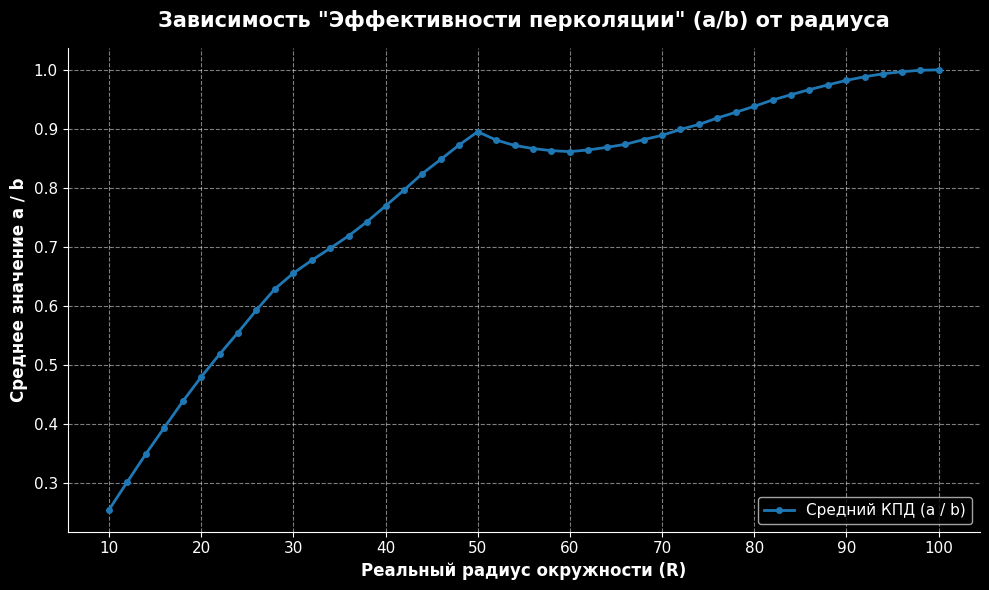

In [62]:
radii = list(range(min_x, max_x + 1, step))

# Создаем фигуру
plt.figure(figsize=(10, 6))

# Строим график.
plt.plot(radii, result, marker='o', linestyle='-', color='#1f77b4', linewidth=2, markersize=4, label='Средний КПД (a / b)')

plt.title('Зависимость "Эффективности перколяции" (a/b) от радиуса', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Реальный радиус окружности (R)', fontsize=12, fontweight='bold')
plt.ylabel('Среднее значение a / b', fontsize=12, fontweight='bold')

# Создаем деления с шагом 10 (10, 20, 30 ... 100), чтобы текст не наслаивался
x_ticks = list(range(10, 101, 10))
plt.xticks(x_ticks, fontsize=11)
plt.yticks(fontsize=11)

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11, loc='lower right')

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()